In [21]:
import seaborn as sns
import numpy as  np 
import pandas as pd 
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv("../data/silver/cleaned_data.csv")
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits
0,5,11.051381,0.230652,Organic,3.890460,3
1,4,3.429316,0.391001,Social,8.478174,0
2,4,1.621052,0.397986,Organic,9.636170,2
3,5,3.629279,0.180458,Organic,2.071925,3
4,5,4.235843,0.291541,Paid,1.960654,5


In [23]:
df.describe()

,Page Views,Session Duration,Bounce Rate,Time on Page,Previous Visits
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.950500,3.022045,0.284767,4.027439,1.978500
std,2.183903,3.104518,0.159781,2.887422,1.432852
min,0.000000,0.003613,0.007868,0.068515,0.000000
25%,3.000000,0.815828,0.161986,1.935037,1.000000
50%,5.000000,1.993983,0.266375,3.315316,2.000000
75%,6.000000,4.197569,0.388551,5.414627,3.000000
max,14.000000,20.290516,0.844939,24.796182,9.000000


In [24]:
df['Avg Time'] = np.where(
    df['Page Views'] > 0,                     
    df['Time on Page'] / df['Page Views'],    
    0                       
)

In [25]:
df.isnull().sum()

Page Views          0
Session Duration    0
Bounce Rate         0
Traffic Source      0
Time on Page        0
Previous Visits     0
Avg Time            0
dtype: int64

In [26]:
df.describe()

,Page Views,Session Duration,Bounce Rate,Time on Page,Previous Visits,Avg Time
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.950500,3.022045,0.284767,4.027439,1.978500,1.040702
std,2.183903,3.104518,0.159781,2.887422,1.432852,1.164782
min,0.000000,0.003613,0.007868,0.068515,0.000000,0.000000
25%,3.000000,0.815828,0.161986,1.935037,1.000000,0.383455
50%,5.000000,1.993983,0.266375,3.315316,2.000000,0.702884
75%,6.000000,4.197569,0.388551,5.414627,3.000000,1.280261
max,14.000000,20.290516,0.844939,24.796182,9.000000,12.521118


In [ ]:
# # Step 2: Return target using last 1 month previous visits and drop Previous vists column due to data leakage 
# df["Return"] = (df["Previous Visits"] > 1).astype(int)
# df = df.drop(columns=["Previous Visits"])

In [ ]:
# t1 = df['Avg Time'].quantile(0.5)
# t2 = df['Avg Time'].quantile(0.75) 
# df['Return'] = ( ((df['Previous Visits'] > 1) & (df['Avg Time'] > t1)) | (df['Avg Time'] > t2) ).astype(int) 
# df = df.drop(columns=["Previous Visits"])
# df = df.drop(columns=["Avg Time"])

In [27]:
t1 = df['Avg Time'].quantile(0.5)
t2 = df['Avg Time'].quantile(0.75) 
df['Return'] = (
    (df['Avg Time'] > t2) |
    ((df['Avg Time'] > t1) & (df['Bounce Rate'] < 0.3))
).astype(int)
df = df.drop(columns=["Avg Time"])
df = df.drop(columns=["Bounce Rate"])

In [28]:
num_cols = df.select_dtypes(include=['int64', 'float64'])
num_cols.corr(method='spearman')

,Page Views,Session Duration,Time on Page,Previous Visits,Return
Page Views,1.000000,-0.007402,0.020028,0.026353,-0.406554
Session Duration,-0.007402,1.000000,0.004357,-0.013845,0.015497
Time on Page,0.020028,0.004357,1.000000,-0.039335,0.620299
Previous Visits,0.026353,-0.013845,-0.039335,1.000000,-0.049784
Return,-0.406554,0.015497,0.620299,-0.049784,1.000000


In [14]:
percentages = df['Return'].value_counts(normalize=True) * 100
print(percentages)

Return
0    60.7
1    39.3
Name: proportion, dtype: float64


In [15]:
df.head()

,Page Views,Session Duration,Traffic Source,Time on Page,Avg Time,Return
0,5,11.051381,Organic,3.890460,0.778092,1
1,4,3.429316,Social,8.478174,2.119544,1
2,4,1.621052,Organic,9.636170,2.409042,1
3,5,3.629279,Organic,2.071925,0.414385,0
4,5,4.235843,Paid,1.960654,0.392131,0


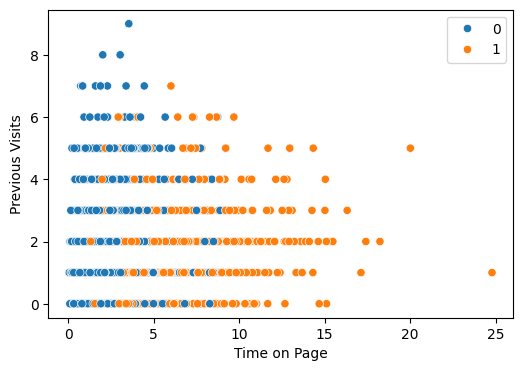

In [30]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Time on Page',y='Previous Visits', hue = 'Return', data= df)
plt.legend()
plt.show()

In [32]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='Time on Page',
    y='Page Views',
    z='Previous Visits',
    color='Return'   # return vs not return
)

fig.show()

### after seeing the data --- data overlaped

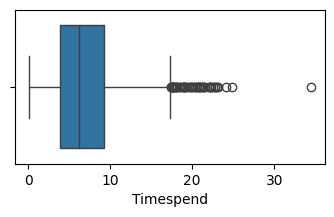

In [57]:
#for single column boxplot 
plt.figure(figsize=(4,2))
sns.boxplot(x=df['Timespend'])
plt.show()

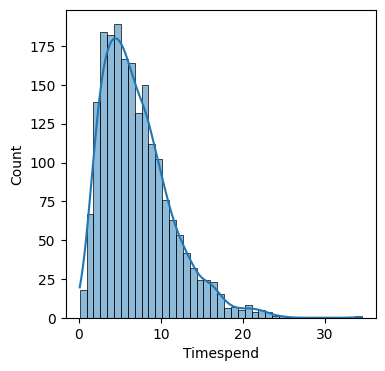

In [58]:
plt.figure(figsize=(4,4))
sns.histplot(df['Timespend'], kde=True)
plt.show()

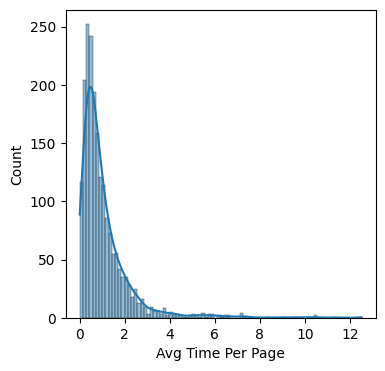

In [59]:
plt.figure(figsize=(4,4))
sns.histplot(df['Avg Time Per Page'], kde=True)
plt.show()

In [25]:
#gold data stores parquet format in gold layer---because parquet format fast , take less size and big data frindly  

#pip install pyarrow---needded environment
 
#df.to_parquet("data/gold/feature_data.parquet", index=False)

In [33]:
df.to_csv("../data/gold/feature_data.csv", index=False)